
STEP 1: Import Dataset

In [2]:
import nltk
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

STEP 2: Import Required Libraries

In [3]:
import math
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import movie_reviews
from nltk.util import ngrams

STEP 3: Load Movie Review Dataset

In [5]:
documents = []

for fileid in movie_reviews.fileids():
    documents.append(movie_reviews.raw(fileid).lower())

print("Total Reviews:", len(documents))
print("Categories:", movie_reviews.categories())

Total Reviews: 2000
Categories: ['neg', 'pos']


In [5]:
# Get first file id
file_id = movie_reviews.fileids()[0]

print("File ID:", file_id)
print("Category:", movie_reviews.categories(file_id))
print("\nReview Text:\n")

print(movie_reviews.raw(file_id))

File ID: neg/cv000_29416.txt
Category: ['neg']

Review Text:

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fan

In [9]:
index = 1
file_id = movie_reviews.fileids()[index]

print(movie_reviews.raw(file_id)[:500])

the happy bastard's quick movie review 
damn that y2k bug . 
it's got a head start in this movie starring jamie lee curtis and another baldwin brother ( william this time ) in a story regarding a crew of a tugboat that comes across a deserted russian tech ship that has a strangeness to it when they kick the power back on . 
little do they know the power within . . . 
going for the gore and bringing on a few action sequences here and there , virus still feels very empty , like a movie going for a


STEP 4: Train–Test Split

In [8]:
train_docs = documents[:1600]   # 80% training
test_docs  = documents[1600:]   # 20% testing

STEP 5: Tokenization (Domain Text → Words)

In [30]:
def tokenize(docs):
    tokens = []
    for doc in docs:
        tokens.extend(doc.split())
    return tokens

train_tokens = tokenize(train_docs)

STEP 6A: Build Unigram Model

In [31]:
unigram_counts = Counter(train_tokens)
total_words = len(train_tokens)

def unigram_prob(word):
    return unigram_counts[word] / total_words if word in unigram_counts else 0

STEP 6B: Build Bigram Model

In [32]:
bigram_counts = Counter(ngrams(train_tokens, 2))

def bigram_prob(w1, w2):
    return bigram_counts[(w1, w2)] / unigram_counts[w1] if unigram_counts[w1] > 0 else 0

STEP 6C: Build Trigram Model

In [33]:
trigram_counts = Counter(ngrams(train_tokens, 3))

def trigram_prob(w1, w2, w3):
    return trigram_counts[(w1, w2, w3)] / bigram_counts[(w1, w2)] if bigram_counts[(w1, w2)] > 0 else 0

STEP 7: Handle Zero Probability (Very Important)

In [34]:
def safe_prob(p):
    return p if p > 0 else 1e-6

STEP 8: Sentence Probability Functions

In [35]:
def unigram_sentence_prob(sentence):
    prob = 1
    for w in sentence.split():
        prob *= safe_prob(unigram_prob(w))
    return prob

In [36]:
def bigram_sentence_prob(sentence):
    words = sentence.split()
    prob = 1
    for i in range(len(words) - 1):
        prob *= safe_prob(bigram_prob(words[i], words[i+1]))
    return prob

In [37]:
def trigram_sentence_prob(sentence):
    words = sentence.split()
    prob = 1
    for i in range(len(words) - 2):
        prob *= safe_prob(trigram_prob(words[i], words[i+1], words[i+2]))
    return prob

STEP 9: Perplexity Formula

In [38]:
def perplexity(sentence_prob, N):
    return pow(sentence_prob, -1/N)

STEP 10: Average Perplexity on Test Set

In [39]:
def average_perplexity(model_type):
    total = 0
    count = 0

    for doc in test_docs[:50]:   # limit for speed
        words = doc.split()
        if len(words) < 3:
            continue

        sentence = " ".join(words[:10])
        N = len(sentence.split())

        if model_type == "unigram":
            p = unigram_sentence_prob(sentence)
        elif model_type == "bigram":
            p = bigram_sentence_prob(sentence)
        else:
            p = trigram_sentence_prob(sentence)

        total += perplexity(p, N)
        count += 1

    return total / count

STEP 11: Compute Model Scores

In [40]:
unigram_pp = average_perplexity("unigram")
bigram_pp = average_perplexity("bigram")
trigram_pp = average_perplexity("trigram")

print("Unigram Perplexity:", unigram_pp)
print("Bigram Perplexity:", bigram_pp)
print("Trigram Perplexity:", trigram_pp)

Unigram Perplexity: 1667.203240516056
Bigram Perplexity: 1009.5299955445942
Trigram Perplexity: 10964.75771465467


STEP 12: Graph Comparison

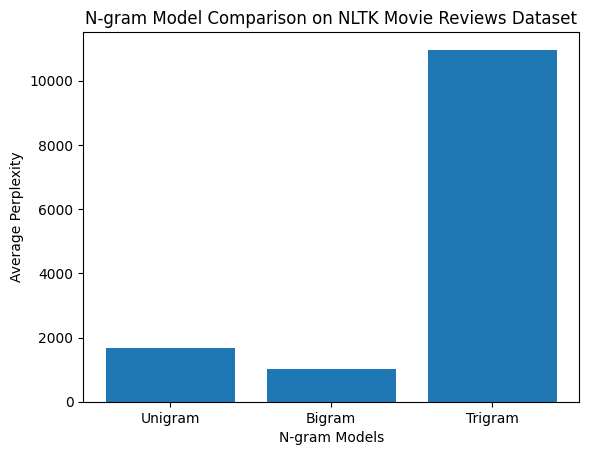

In [41]:
models = ["Unigram", "Bigram", "Trigram"]
perplexities = [unigram_pp, bigram_pp, trigram_pp]

plt.figure()
plt.bar(models, perplexities)
plt.xlabel("N-gram Models")
plt.ylabel("Average Perplexity")
plt.title("N-gram Model Comparison on NLTK Movie Reviews Dataset")
plt.show()